In [8]:
import numpy as np 
import pandas as pd 
import joblib 
from pathlib import Path 

output_dir = Path(r"C:\f1 new\data") 
xgb = joblib.load(output_dir/"xgb_pit_model.pkl") 
df = pd.read_parquet(output_dir/"f1_gold.parquet") 

print("Ready")

Ready


In [9]:
df.columns

Index(['Year', 'RoundNumber', 'Driver', 'Team', 'LapNumber', 'LapPct',
       'Compound', 'CompoundEncoded', 'TyreLife', 'TyreAgePct',
       'DegradationRate', 'DegradationSlope', 'Position', 'SCInNext3Laps',
       'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall',
       'WillPitNextLap'],
      dtype='object')

In [10]:
sc_prob= (
    df.groupby('RoundNumber')['SCInNext3Laps'].mean().reset_index()
) 

sc_prob.columns = ['RoundNumber', 'SCProbability'] 
print(sc_prob.sort_values('SCProbability', ascending=False).head(10))


    RoundNumber  SCProbability
2             3       0.106081
14           15       0.087417
8             9       0.079842
16           17       0.074453
20           21       0.074370
11           12       0.069985
22           23       0.065008
18           19       0.064439
1             2       0.060193
7             8       0.056754


In [11]:
import joblib

model = joblib.load(output_dir / "xgb_pit_model.pkl")
print("Model loaded ")

Model loaded 


In [12]:
joblib.dump(xgb, output_dir / "xgb_pit_model.pkl")
print("Model saved ")

Model saved 


In [13]:
def simulate_race(
    driver_laps: pd.DataFrame,
    model,
    feature_cols: list,
    n_simulations: int = 10000
) -> dict:
    pit_votes = np.zeros(len(driver_laps))

    for _ in range(n_simulations):
        for i, (_, lap) in enumerate(driver_laps.iterrows()):
            features  = lap[feature_cols].values.reshape(1, -1)
            pit_proba = model.predict_proba(features)[0][1]

            sc_event = np.random.random() < lap['SCInNext3Laps'] * 0.3
            if sc_event:
                pit_proba = min(1.0, pit_proba * 1.5)

            if np.random.random() < pit_proba:
                pit_votes[i] += 1
                i += 5 
            
            else : 
                i += 1 

    pit_probability = pit_votes / n_simulations
    best_lap_index  = np.argmax(pit_probability)
    best_lap        = driver_laps.iloc[best_lap_index]['LapNumber']  
    best_prob       = pit_probability[best_lap_index]

    return {
        'optimal_pit_lap' : int(best_lap),
        'probability'     : round(best_prob, 3),
        'pit_distribution': pit_probability,
        'lap_numbers'     : driver_laps['LapNumber'].values
    }

In [14]:
feature_cols = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

year       = 2024
round_num  = 1
driver     = 'VER'

driver_laps = df[
    (df['Year'] == year) &
    (df['RoundNumber'] == round_num) &
    (df['Driver'] == driver)
].sort_values('LapNumber').reset_index(drop=True)

print(f"Simulating: {year} R{round_num:02d} {driver}")
print(f"Laps: {len(driver_laps)}")

result = simulate_race(driver_laps, model, feature_cols)

print(f"\nOptimal Pit Lap : {result['optimal_pit_lap']}")
print(f"Probability     : {result['probability']*100:.1f}%")

Simulating: 2024 R01 VER
Laps: 57

Optimal Pit Lap : 13
Probability     : 86.6%


In [15]:
df.columns

Index(['Year', 'RoundNumber', 'Driver', 'Team', 'LapNumber', 'LapPct',
       'Compound', 'CompoundEncoded', 'TyreLife', 'TyreAgePct',
       'DegradationRate', 'DegradationSlope', 'Position', 'SCInNext3Laps',
       'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall',
       'WillPitNextLap'],
      dtype='object')

In [16]:
ver_pits = df[
    (df['Year'] == 2024) &
    (df['RoundNumber'] == 1) &
    (df['Driver'] == 'VER') &
    (df['WillPitNextLap'] == 1)
][['LapNumber', 'TyreLife', 'Compound', 'DegradationRate', 'Position']]

print("VER Pit Stops — 2024 R01 Bahrain:")
print(ver_pits)

VER Pit Stops — 2024 R01 Bahrain:
       LapNumber  TyreLife Compound  DegradationRate  Position
45709       16.0      19.0     SOFT            0.415       1.0
45729       36.0      19.0     HARD            0.922       1.0


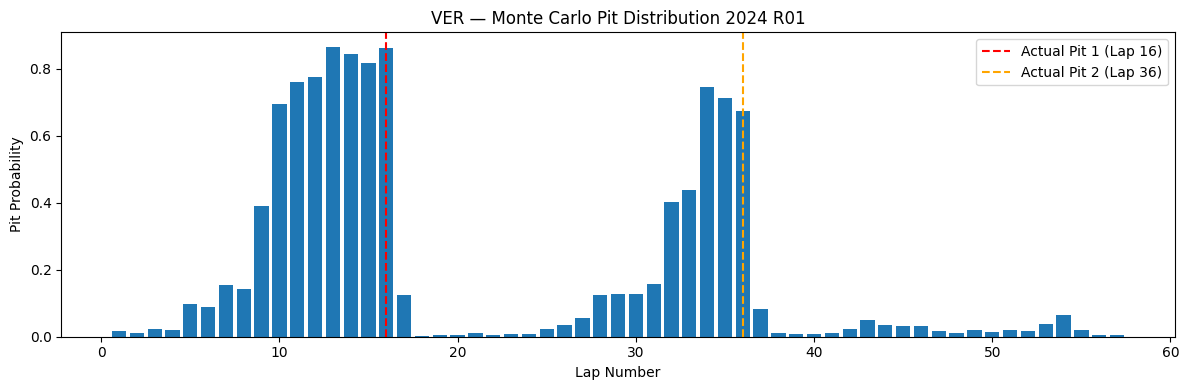

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.bar(result['lap_numbers'], result['pit_distribution'])
plt.axvline(x=16, color='red', linestyle='--', label='Actual Pit 1 (Lap 16)')
plt.axvline(x=36, color='orange', linestyle='--', label='Actual Pit 2 (Lap 36)')
plt.xlabel('Lap Number')
plt.ylabel('Pit Probability')
plt.title('VER — Monte Carlo Pit Distribution 2024 R01')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
df.columns

Index(['Year', 'RoundNumber', 'Driver', 'Team', 'LapNumber', 'LapPct',
       'Compound', 'CompoundEncoded', 'TyreLife', 'TyreAgePct',
       'DegradationRate', 'DegradationSlope', 'Position', 'SCInNext3Laps',
       'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall',
       'WillPitNextLap'],
      dtype='object')

In [24]:
def simulate_race(
        driver_laps: pd.DataFrame, 
        model, 
        feature_cols=list, 
        n_simulations=10000
) -> dict:
    pit_votes = np.zeros(len(driver_laps))

    x_all = driver_laps[feature_cols].values.astype(np.float32)
    all_probs = model.predict_proba(x_all)[:, 1]

    sc_mask = driver_laps['SCInNext3Laps'].values > 0
    all_probs[sc_mask] *= np.minimum(1.0, all_probs[sc_mask] * 1.5)

    for _ in range(n_simulations):
        random_vals = np.random.rand(len(driver_laps))
        pit_laps = np.where(random_vals < all_probs)[0]
        pit_votes[pit_laps] += 1        

    pit_probability = pit_votes / n_simulations
    best_lap_index = np.argmax(pit_probability)
    best_lap = driver_laps.iloc[best_lap_index]['LapNumber']
    best_prob = pit_probability[best_lap_index]

    return {
        'optimal_pit_lap': int(best_lap),
        'probability': round(best_prob, 3),
        'pit_distribution': pit_probability,
        'lap_numbers': driver_laps['LapNumber'].values
    }

In [25]:
import time

feature_cols = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

year      = 2024
round_num = 1
driver    = 'VER'

driver_laps = df[
    (df['Year'] == year) &
    (df['RoundNumber'] == round_num) &
    (df['Driver'] == driver)
].sort_values('LapNumber').reset_index(drop=True)

print(f"Simulating: {year} R{round_num:02d} {driver}")
print(f"Laps: {len(driver_laps)}")

start  = time.time()
result = simulate_race(driver_laps, model, feature_cols)
elapsed = time.time() - start

print(f"\nOptimal Pit Lap : {result['optimal_pit_lap']}")
print(f"Probability     : {result['probability']*100:.1f}%")
print(f"Time taken      : {elapsed:.2f} sec")

Simulating: 2024 R01 VER
Laps: 57

Optimal Pit Lap : 13
Probability     : 87.3%
Time taken      : 0.17 sec


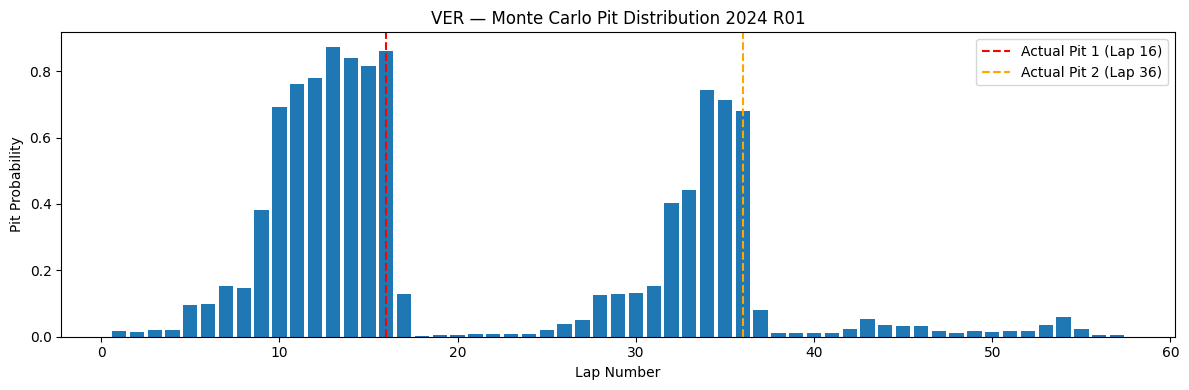

In [26]:
plt.figure(figsize=(12, 4)) 
plt.bar(result['lap_numbers'] , result['pit_distribution'])
plt.axvline(x=16, color='red', linestyle='--', label='Actual Pit 1 (Lap 16)')
plt.axvline(x=36, color='orange', linestyle='--', label='Actual Pit 2 (Lap 36)')
plt.xlabel('Lap Number')
plt.ylabel('Pit Probability')
plt.title('VER — Monte Carlo Pit Distribution 2024 R01')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
feature_cols = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

year      = 2025
round_num = 1
driver    = 'NOR'

driver_laps = df[
    (df['Year'] == year) &
    (df['RoundNumber'] == round_num) &
    (df['Driver'] == driver)
].sort_values('LapNumber').reset_index(drop=True)

print(f"Simulating: {year} R{round_num:02d} {driver}")
print(f"Laps: {len(driver_laps)}")

start  = time.time()
result = simulate_race(driver_laps, model, feature_cols)
elapsed = time.time() - start

print(f"\nOptimal Pit Lap : {result['optimal_pit_lap']}") 
print(f"Probability     : {result['probability']*100:.1f}%") 
print(f"Time taken      : {elapsed:.2f} sec")

Simulating: 2025 R01 NOR
Laps: 41

Optimal Pit Lap : 33
Probability     : 87.3%
Time taken      : 0.48 sec


In [29]:
print(driver_laps[['Year', 'RoundNumber', 'Driver', 'LapNumber']].head())

   Year  RoundNumber Driver  LapNumber
0  2025            1    NOR        1.0
1  2025            1    NOR        8.0
2  2025            1    NOR        9.0
3  2025            1    NOR       10.0
4  2025            1    NOR       11.0


In [30]:
raw_nor = df[(df['Year']==2025) & (df['RoundNumber']==1) & (df['Driver']=='NOR')]
print(raw_nor[['LapNumber', 'DegradationRate', 'DegradationSlope']].head(10))

       LapNumber  DegradationRate  DegradationSlope
70380        1.0             0.00            0.0000
70381        8.0             1.64            0.0457
70382        9.0             0.00            0.0457
70383       10.0             0.00            0.0457
70384       11.0             0.00            0.0457
70385       12.0             0.00            0.0457
70386       13.0             0.00            0.0457
70387       14.0             0.00            0.0457
70388       15.0             0.00            0.0457
70389       16.0             0.00            0.0457


In [31]:
raw_nor_full = df[(df['Year']==2025) & (df['RoundNumber']==1) & (df['Driver']=='NOR')]
print(raw_nor_full[['LapNumber']].to_string())

       LapNumber
70380        1.0
70381        8.0
70382        9.0
70383       10.0
70384       11.0
70385       12.0
70386       13.0
70387       14.0
70388       15.0
70389       16.0
70390       17.0
70391       18.0
70392       19.0
70393       20.0
70394       21.0
70395       22.0
70396       23.0
70397       24.0
70398       25.0
70399       26.0
70400       27.0
70401       28.0
70402       29.0
70403       30.0
70404       31.0
70405       32.0
70406       33.0
70407       34.0
70408       35.0
70409       42.0
70410       43.0
70411       44.0
70412       45.0
70413       46.0
70414       47.0
70415       52.0
70416       53.0
70417       54.0
70418       55.0
70419       56.0
70420       57.0


In [32]:
rc = pd.read_parquet(r"C:\f1 new\data\f1_race_control.parquet")
print(rc[(rc['Year']==2025) & (rc['RoundNumber']==1)])

                    Time Category  \
5978 2025-03-16 03:15:05    Other   
5979 2025-03-16 03:15:08      Drs   
5980 2025-03-16 03:20:01     Flag   
5981 2025-03-16 03:25:03     Flag   
5982 2025-03-16 03:25:08     Flag   
...                  ...      ...   
6086 2025-03-16 05:58:19    Other   
6087 2025-03-16 05:58:32    Other   
6088 2025-03-16 05:59:02    Other   
6089 2025-03-16 05:59:50    Other   
6090 2025-03-16 06:00:29     Flag   

                                                Message    Status       Flag  \
5978                                LOW GRIP CONDITIONS      None       None   
5979                                       DRS DISABLED  DISABLED       None   
5980                        GREEN LIGHT - PIT EXIT OPEN      None      GREEN   
5981                          YELLOW IN TRACK SECTOR 17      None     YELLOW   
5982                           CLEAR IN TRACK SECTOR 17      None      CLEAR   
...                                                 ...       ...        ..

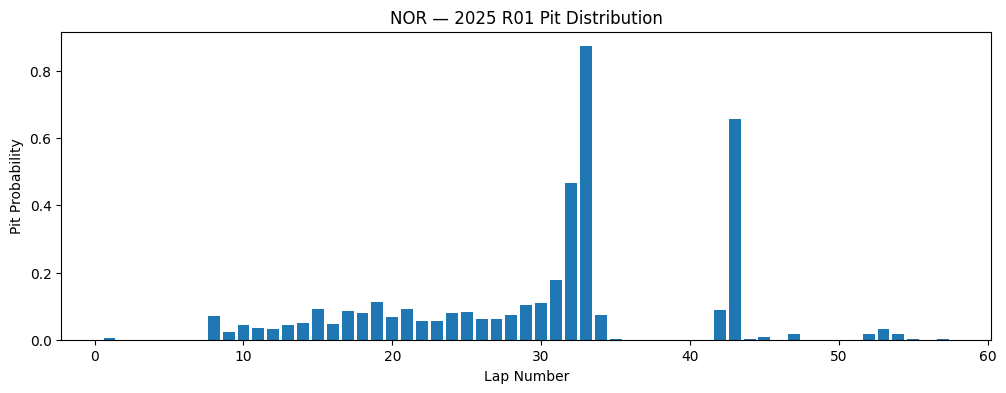

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.bar(result['lap_numbers'], result['pit_distribution'])
plt.title(f"{driver} — {year} R{round_num:02d} Pit Distribution")
plt.xlabel("Lap Number")
plt.ylabel("Pit Probability")
plt.show()

In [34]:
feature_cols = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]

year      = 2025
round_num = 3
driver    = 'HAM'

driver_laps = df[
    (df['Year'] == year) &
    (df['RoundNumber'] == round_num) &
    (df['Driver'] == driver)
].sort_values('LapNumber').reset_index(drop=True)

print(f"Simulating: {year} R{round_num:02d} {driver}")
print(f"Laps: {len(driver_laps)}")

start  = time.time()
result = simulate_race(driver_laps, model, feature_cols)
elapsed = time.time() - start

print(f"\nOptimal Pit Lap : {result['optimal_pit_lap']}") 
print(f"Probability     : {result['probability']*100:.1f}%") 
print(f"Time taken      : {elapsed:.2f} sec")

Simulating: 2025 R03 HAM
Laps: 53

Optimal Pit Lap : 30
Probability     : 67.8%
Time taken      : 0.18 sec


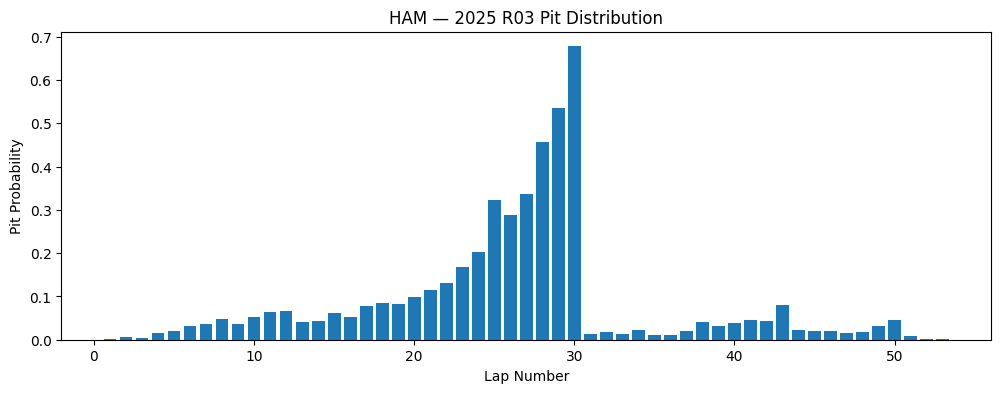

In [35]:
plt.figure(figsize=(12,4))
plt.bar(result['lap_numbers'], result['pit_distribution'])
plt.title(f"HAM — 2025 R03 Pit Distribution")
plt.xlabel("Lap Number")
plt.ylabel("Pit Probability")
plt.show()

In [40]:
print(driver_laps[
    (driver_laps['Year'] == 2025) & 
    (driver_laps['RoundNumber'] == 3) & 
    (driver_laps['Driver'] == 'HAM') & 
    (driver_laps['LapNumber'] == 30)
])

    Year  RoundNumber Driver     Team  LapNumber  LapPct Compound  \
29  2025            3    HAM  Ferrari       30.0   0.566     HARD   

    CompoundEncoded  TyreLife  TyreAgePct  DegradationRate  DegradationSlope  \
29                2      30.0       0.667            0.911               0.0   

    Position  SCInNext3Laps  TrackTemp  AirTemp  Humidity  WindSpeed  \
29       4.0              0       19.7     14.6      77.0        0.7   

    Rainfall  WillPitNextLap  
29     False               0  


In [41]:
actual_pit = driver_laps[driver_laps['WillPitNextLap'] == 1]
print(actual_pit[['LapNumber', 'WillPitNextLap']])

    LapNumber  WillPitNextLap
28       29.0               1
